# Estimación de probabilidades de campeonato del Mundial FIFA 2026 mediante simulación de Monte Carlo basada en ratings Elo

**Autor:** Gus (`gvar1965`) · Carrera de Especialización en Inteligencia Artificial (CEIA), FIUBA — *Análisis de Datos*
**Fecha:** junio de 2026

---

### Resumen

Se estima la probabilidad de que cada una de las 48 selecciones se consagre campeona del
Mundial FIFA 2026 mediante **simulación de Monte Carlo**, partiendo del estado del torneo en
curso (al 23 de junio de 2026, con los 12 grupos habiendo disputado 2 de sus 3 fechas; 48 partidos de grupos jugados y 24 por jugar). Cada partido se modela con dos distribuciones de Poisson
independientes cuyas intensidades se derivan de la diferencia de **rating Elo** entre los
contendientes, calibradas de modo que el cociente de goles esperados reproduzca la forma
clásica del Elo. A partir del estado actual de los 12 grupos se simulan los encuentros
restantes, la clasificación (dos primeros de cada grupo más los ocho mejores terceros) y la
totalidad de la fase eliminatoria respetando la plantilla oficial de la Ronda de 32. Sobre
$N=10^{6}$ réplicas independientes se obtiene que **Argentina** ($30{,}1\%$), **Francia**
($24{,}6\%$), **España** ($14{,}0\%$) e **Inglaterra** ($12{,}0\%$) concentran cerca del
$81\%$ de los títulos. Se reportan los **errores estándar de Monte Carlo** e
**intervalos de confianza del 95\%**, se verifica la **convergencia** del estimador y se
analiza la **sensibilidad** a la ventaja de localía. La implementación del motor utiliza
únicamente la biblioteca estándar de Python y es íntegramente reproducible (semilla fija,
entorno fijado con `uv`).

**Palabras clave:** Monte Carlo · rating Elo · modelo de Poisson · pronóstico deportivo ·
Mundial 2026 · simulación estocástica.

## 1. Introducción

El pronóstico de resultados en fútbol de selecciones combina dos ingredientes bien estudiados
en la literatura: un **sistema de rating** que sintetiza la fuerza relativa de los equipos y un
**modelo generativo de goles** que traduce esa fuerza en marcadores. El rating Elo, originado
en ajedrez [1] y adaptado al fútbol por *eloratings.net* [6], ha mostrado capacidad predictiva
competitiva frente a otros sistemas de ranking [4, 5]. Por su parte, el modelado de goles
mediante distribuciones de Poisson se remonta a Maher [2] y fue refinado por Dixon y Coles [3].

El Mundial 2026 introduce un formato inédito de **48 selecciones** en 12 grupos, con
clasificación de los dos primeros de cada grupo y los ocho mejores terceros, seguido de una
fase eliminatoria de 32 equipos [8]. Este trabajo aborda la pregunta: *dado el estado actual
del torneo, ¿con qué probabilidad se consagra campeona cada selección?* Dada la complejidad
combinatoria de la fase final, una solución analítica cerrada es impracticable; se recurre
entonces a **simulación de Monte Carlo** [9].

**Contribución.** Se presenta (i) un modelo de partido Elo→Poisson calibrado y parsimonioso,
(ii) una simulación íntegra del torneo desde su estado actual hasta la final respetando el
*bracket* oficial, y (iii) una estimación de las probabilidades de campeonato con
cuantificación rigurosa del error de Monte Carlo, análisis de convergencia y de sensibilidad.

## 2. Datos

Se emplean los siguientes insumos (directorio `data/`, en formato **Parquet**), correspondientes
a un *snapshot* del torneo tomado alrededor del **20 de junio de 2026**:

| Insumo | Descripción | Fuente |
|--------|-------------|--------|
| `elo.parquet`      | Rating Elo de las 48 selecciones (escala clásica) | worldfootballrankings [7] |
| `groups.parquet`   | Posiciones actuales de los 12 grupos (PJ, Pts, GF, GC) | CBS Sports [10], NBC Sports [11] |
| `fixtures.parquet` | Partidos de grupo aún no disputados | CBS Sports [10] |
| `bracket.json`     | Plantilla oficial de la Ronda de 32 y llave hasta la final | worldcuppass [12] |
| `history.parquet`  | 49.477 partidos internacionales (1872–2026), para la calibración | martj42 [14] |

Las fuentes editables a mano viven en `data/sources/*.csv` y se convierten a Parquet con
`convert_to_parquet.py`. Trece selecciones menores sin Elo publicado en la misma escala reciben
un valor **estimado** (columna `fuente`); el impacto sobre las favoritas es despreciable (Sección 5).

In [1]:
import time, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import wcsim

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})
Z95 = 1.959963985  # cuantil normal estandar para IC del 95%

data = wcsim.load_all()
elo, groups, fixtures, bracket = data["elo"], data["groups"], data["fixtures"], data["bracket"]
print(f"{len(elo)} selecciones · {len(groups)} grupos · "
      f"{len(fixtures)} partidos de grupo por jugar · "
      f"{len(bracket['r32'])} cruces en la Ronda de 32")

elo_df = pd.DataFrame(sorted(elo.items(), key=lambda x: -x[1]), columns=["Selección", "Elo"])
print("\nTop-10 por Elo:")
display(elo_df.head(10).style.format({"Elo": "{:.0f}"}).hide(axis="index"))

48 selecciones · 12 grupos · 0 partidos de grupo por jugar · 16 cruces en la Ronda de 32

Top-10 por Elo:


Selección,Elo
Argentina,1889
France,1887
Spain,1856
England,1848
Brazil,1772
Morocco,1770
Netherlands,1764
Portugal,1755
Germany,1744
Belgium,1734


## 3. Metodología

### 3.1 Sistema de rating Elo

A cada selección $i$ se le asocia un rating $R_i \in \mathbb{R}$. Para un enfrentamiento entre
$A$ y $B$, el Elo define el **puntaje esperado** de $A$ (con el empate valuado en medio punto)
como función exclusiva de la diferencia $\Delta = R_A - R_B$:

$$E_A(\Delta) \;=\; \frac{1}{1 + 10^{-\Delta/400}}, \qquad E_B = 1 - E_A. \tag{1}$$

La constante $400$ fija la escala: una ventaja de $\Delta = 400$ implica $E_A \approx 0{,}91$.
Las sedes (USA, México, Canadá) reciben una **ventaja de localía** $h$ ($=60$ por defecto)
solo cuando juegan **en su propio país**:

$$\tilde R_i = R_i + h\,\mathbb{1}\{\text{la sede del partido está en el país de } i\}.$$

En la fase de grupos cada anfitrión juega de local; en la fase eliminatoria la sede está
fijada por número de partido según el calendario oficial [13] (`venue` en `bracket.json`), de
modo que un anfitrión puede jugar fuera de su país: la final y todas las rondas desde cuartos
se disputan en EE. UU., mientras que solo seis cruces de las primeras rondas ocurren en México
(M75, M79, M92) o Canadá (M83, M85, M96).

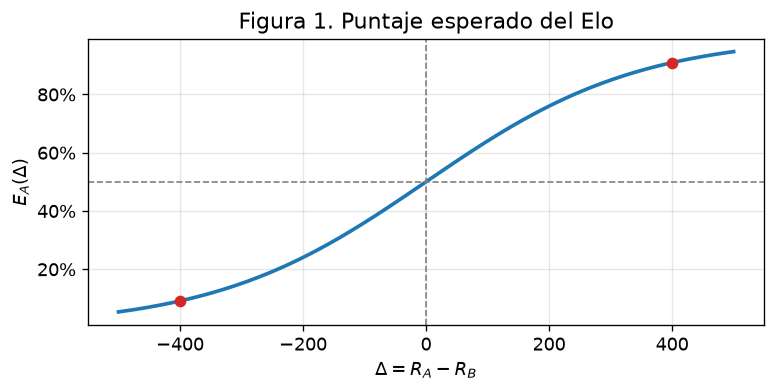

In [2]:
# Figura 1 — funcion logistica del Elo (Ec. 1)
d = np.linspace(-500, 500, 400)
fig, ax = plt.subplots(figsize=(6.6, 3.4))
ax.plot(d, 1/(1+10**(-d/400)), lw=2.2, color="#1f77b4")
ax.axhline(0.5, color="grey", ls="--", lw=1); ax.axvline(0, color="grey", ls="--", lw=1)
ax.scatter([400, -400], [1/(1+10**(-400/400)), 1/(1+10**(400/400))], color="#d62728", zorder=5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel(r"$\Delta = R_A - R_B$"); ax.set_ylabel(r"$E_A(\Delta)$")
ax.set_title("Figura 1. Puntaje esperado del Elo")
plt.tight_layout(); plt.savefig("charts/01_curva_elo.png", bbox_inches="tight"); plt.show()

### 3.2 Modelo generativo de partido (Elo → Poisson)

El puntaje esperado (Ec. 1) no produce un **marcador**, necesario para los criterios de
desempate de la fase de grupos. Siguiendo la tradición de Maher [2] y Dixon–Coles [3],
modelamos los goles de cada equipo como variables de Poisson independientes:

$$G_A \sim \text{Poisson}(\lambda_A), \qquad G_B \sim \text{Poisson}(\lambda_B), \tag{2}$$

con intensidades derivadas de la diferencia de Elo $\tilde\Delta = \tilde R_A - \tilde R_B$:

$$\lambda_A = \mu \cdot 10^{\,\tilde\Delta/800}, \qquad
  \lambda_B = \mu \cdot 10^{-\tilde\Delta/800}. \tag{3}$$

El parámetro $\mu = 1{,}35$ es el nivel de goles esperados entre rivales parejos
($\tilde\Delta=0$). La elección del exponente $\pm\tilde\Delta/800$ es deliberada: implica

$$\frac{\lambda_A}{\lambda_B} = 10^{\,\tilde\Delta/400}, \tag{4}$$

es decir, el **cociente de goles esperados reproduce la escala del Elo clásico** (Ec. 1),
manteniendo además el total esperado $\lambda_A\lambda_B = \mu^2$ aproximadamente invariante.
El empate emerge endógenamente cuando $G_A = G_B$. En la fase eliminatoria, un empate se
resuelve por penales asignando la victoria a $A$ con probabilidad $E_A(\tilde\Delta)$.

Dado el modelo (2), las probabilidades de victoria/empate/derrota se obtienen analíticamente:

$$P(G_A > G_B),\; P(G_A = G_B),\; P(G_A < G_B)
  \;=\; \sum_{a,b\ge 0} \frac{e^{-\lambda_A}\lambda_A^{a}}{a!}\,
  \frac{e^{-\lambda_B}\lambda_B^{b}}{b!}\;\mathbb{1}\{\cdot\}. \tag{5}$$

Partido,λ_A,λ_B,P(gana A),P(empate),P(gana B)
Argentina – Brazil,1.890000,0.960000,59.1%,22.1%,18.8%
Spain – England,1.380000,1.320000,38.6%,25.8%,35.6%
France – USA,1.890000,0.960000,59.2%,22.1%,18.7%
Mexico – Germany,1.510000,1.210000,44.1%,25.4%,30.5%
Morocco – Croatia,1.670000,1.090000,51.0%,24.2%,24.7%


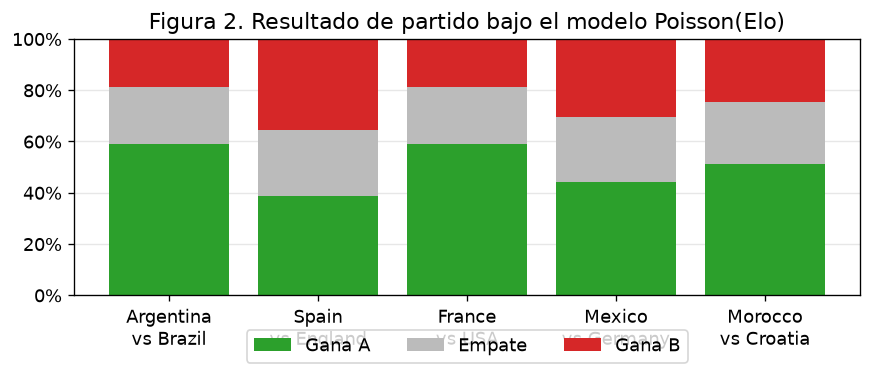

In [3]:
# Ec. (5): probabilidades G/E/P analiticas a partir de las intensidades de Poisson
def pois_pmf(k, lam):
    return math.exp(-lam) * lam**k / math.factorial(k)

def wdl(a, b, model, maxg=25):
    la, lb = model.lambdas(a, b)
    pa = [pois_pmf(k, la) for k in range(maxg)]
    pb = [pois_pmf(k, lb) for k in range(maxg)]
    win  = sum(pa[i]*pb[j] for i in range(maxg) for j in range(maxg) if i > j)
    draw = sum(pa[i]*pb[i] for i in range(maxg))
    loss = sum(pa[i]*pb[j] for i in range(maxg) for j in range(maxg) if i < j)
    total = win + draw + loss   # normaliza y absorbe el residuo de las colas truncadas
    return win/total, draw/total, loss/total

model = wcsim.MatchModel(elo)
pares = [("Argentina","Brazil"),("Spain","England"),("France","USA"),
         ("Mexico","Germany"),("Morocco","Croatia")]
rows = []
for a, b in pares:
    la, lb = model.lambdas(a, b); w, dr, l = wdl(a, b, model)
    rows.append([f"{a} – {b}", round(la,2), round(lb,2), w, dr, l])
tab = pd.DataFrame(rows, columns=["Partido","λ_A","λ_B","P(gana A)","P(empate)","P(gana B)"])
display(tab.style.format({"P(gana A)":"{:.1%}","P(empate)":"{:.1%}","P(gana B)":"{:.1%}"}).hide(axis="index"))

# Figura 2 — descomposicion G/E/P
W=[r[3] for r in rows]; D=[r[4] for r in rows]; L=[r[5] for r in rows]
labels=[f"{a}\nvs {b}" for a,b in pares]
fig, ax = plt.subplots(figsize=(7.4, 3.4))
ax.bar(labels, W, label="Gana A", color="#2ca02c")
ax.bar(labels, D, bottom=W, label="Empate", color="#bbbbbb")
ax.bar(labels, L, bottom=[w+d for w,d in zip(W,D)], label="Gana B", color="#d62728")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_ylim(0,1)
ax.set_title("Figura 2. Resultado de partido bajo el modelo Poisson(Elo)")
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5,-0.30))
plt.tight_layout(); plt.savefig("charts/02_partido_gep.png", bbox_inches="tight"); plt.show()

### 3.3 Estructura del torneo

**Fase de grupos.** Se parte del estado observado de cada grupo (puntos, GF, GC acumulados) y
se simulan únicamente los partidos restantes según (2)–(3). El ordenamiento final de cada grupo
sigue los criterios oficiales aproximados: **puntos → diferencia de gol → goles a favor**, con
el Elo como desempate residual. Clasifican los dos primeros de cada grupo (24 equipos) y los
**ocho mejores terceros** entre los doce, ordenados por el mismo criterio.

**Fase eliminatoria.** Los 32 clasificados se ubican en la **Ronda de 32 oficial**
(`bracket.json`, partidos M73–M88): cada posición está predeterminada como *ganador de grupo*,
*segundo* o *mejor tercero*. Los ocho terceros se asignan a sus ranuras respetando los grupos
admitidos por cada una mediante un *matching* bipartito (algoritmo de Kuhn). La llave se
resuelve partido a partido hasta la final:

$$\text{R32}\,(16) \to \text{8vos}\,(8) \to \text{4tos}\,(4) \to \text{SF}\,(2) \to \text{Final}\,(1).$$

In [4]:
# Una realizacion del torneo (verificacion cualitativa del motor)
rng_demo = random.Random(7)
st, thirds = wcsim.simulate_group_stage(groups, fixtures, model, rng_demo)
champ, fin, sem = wcsim.simulate_knockout(st, thirds, bracket, model, rng_demo)
print("Realización de ejemplo (semilla 7):")
print("  Campeón        :", champ)
print("  Finalistas     :", " y ".join(fin))
print("  Semifinalistas :", ", ".join(sem))

Realización de ejemplo (semilla 7):
  Campeón        : France
  Finalistas     : France y Brazil
  Semifinalistas : France, Portugal, Brazil, Colombia


### 3.4 Estimador de Monte Carlo

Sea $X^{(k)}$ la realización $k$-ésima del torneo y $\mathbb{1}\{X^{(k)}=i\}$ el indicador de
que la selección $i$ resulte campeona. El estimador de la probabilidad de campeonato es la
proporción muestral sobre $N$ réplicas independientes:

$$\hat p_i \;=\; \frac{1}{N}\sum_{k=1}^{N} \mathbb{1}\{X^{(k)} = i\}. \tag{6}$$

Por la ley de los grandes números $\hat p_i \to p_i$ y, al ser $\hat p_i$ una proporción
binomial, su **error estándar de Monte Carlo** y su **intervalo de confianza del 95\%** son

$$\operatorname{SE}(\hat p_i) = \sqrt{\frac{\hat p_i(1-\hat p_i)}{N}}, \qquad
  \text{IC}_{95\%} = \hat p_i \pm z_{0.975}\,\operatorname{SE}(\hat p_i). \tag{7}$$

El error decrece como $\mathcal{O}(N^{-1/2})$. Con $N=10^{6}$, para $\hat p \approx 0{,}28$ se
tiene $\operatorname{SE} \approx 4{,}5\times 10^{-4}$ (es decir, $\pm 0{,}09$ puntos
porcentuales con 95\% de confianza), por lo que la incertidumbre estadística es despreciable
frente a la incertidumbre de modelado.

## 4. Resultados

### 4.1 Probabilidades de campeonato

Se ejecutan $N=10^{6}$ réplicas con semilla fija (`seed=2026`). Para cada selección se registra,
además del título, el avance hasta semifinal y final, lo que permite trazar todo el recorrido
por la grilla. El siguiente bloque realiza una **única pasada** que acumula los conteos (Ec. 6)
y, simultáneamente, almacena estimaciones parciales en puntos de control para el análisis de
convergencia (Sección 4.3).

In [5]:
def run_tracked(N, seed, track, checkpoints, base=1.35, home_adv=60.0):
    # Una pasada de N torneos: devuelve conteos finales + trayectoria de p_i.
    m = wcsim.MatchModel(elo, base=base, home_adv=home_adv)
    rng = random.Random(seed)
    teams = list(elo)
    champ = {t: 0 for t in teams}; final = {t: 0 for t in teams}; semi = {t: 0 for t in teams}
    cps = sorted(checkpoints); xs = []; traj = {t: [] for t in track}; ci = 0
    for i in range(1, N + 1):
        s, th = wcsim.simulate_group_stage(groups, fixtures, m, rng)
        c, f2, s2 = wcsim.simulate_knockout(s, th, bracket, m, rng)
        champ[c] += 1
        for f in f2: final[f] += 1
        for s3 in s2: semi[s3] += 1
        if ci < len(cps) and i == cps[ci]:
            xs.append(i)
            for t in track: traj[t].append(champ[t] / i)
            ci += 1
    return champ, final, semi, xs, traj

N = 1_000_000
TRACK = ["Argentina", "France", "Spain", "England"]
CPS = [1000, 2000, 5000, 10_000, 20_000, 50_000, 100_000, 200_000, 500_000, 1_000_000]

t0 = time.perf_counter()
champ, final, semi, xs, traj = run_tracked(N, 2026, TRACK, CPS)
dt = time.perf_counter() - t0
print(f"N = {N:,} torneos simulados en {dt:.1f} s  ({N/dt:,.0f} torneos/s)")

N = 1,000,000 torneos simulados en 36.0 s  (27,802 torneos/s)


In [6]:
# Tabla 1 — probabilidades con SE e IC95 (Ecs. 6-7)
recs = []
for t in elo:
    k = champ[t]; p = k / N
    se = math.sqrt(p * (1 - p) / N)
    recs.append({"Selección": t, "Elo": elo[t], "Títulos": k, "p̂(campeón)": p,
                 "SE": se, "IC95_lo": p - Z95*se, "IC95_hi": p + Z95*se,
                 "p̂(final)": final[t]/N, "p̂(semi)": semi[t]/N})
df = pd.DataFrame(recs).sort_values("Títulos", ascending=False).reset_index(drop=True)
ncamp = int((df["Títulos"] > 0).sum())
print(f"{ncamp} de {len(elo)} selecciones se consagraron campeonas en al menos un escenario.\n")

def fmt_ci(r):
    return f"[{r['IC95_lo']*100:.2f}; {r['IC95_hi']*100:.2f}]"
show = df.head(15).copy()
show["IC95% (campeón) %"] = show.apply(fmt_ci, axis=1)
cols = ["Selección","Elo","Títulos","p̂(campeón)","IC95% (campeón) %","p̂(final)","p̂(semi)"]
display(show[cols].style.format({"Elo":"{:.0f}","Títulos":"{:,}","p̂(campeón)":"{:.2%}",
        "p̂(final)":"{:.1%}","p̂(semi)":"{:.1%}"}).hide(axis="index")
        .set_caption("Tabla 1. Probabilidades estimadas de campeonato (N = 10⁶, seed 2026)."))

26 de 48 selecciones se consagraron campeonas en al menos un escenario.



Selección,Elo,Títulos,p̂(campeón),IC95% (campeón) %,p̂(final),p̂(semi)
Argentina,1889,"342,981",34.30%,[34.21; 34.39],56.4%,81.8%
France,1887,"229,018",22.90%,[22.82; 22.98],39.8%,59.3%
Spain,1856,"135,723",13.57%,[13.51; 13.64],26.6%,48.9%
England,1848,"127,354",12.74%,[12.67; 12.80],24.3%,50.3%
Brazil,1772,"33,293",3.33%,[3.29; 3.36],9.0%,26.8%
USA,1710,"27,589",2.76%,[2.73; 2.79],8.1%,21.9%
Morocco,1770,"22,093",2.21%,[2.18; 2.24],6.5%,15.0%
Netherlands,1764,"19,130",1.91%,[1.89; 1.94],5.8%,13.7%
Germany,1744,"12,341",1.23%,[1.21; 1.26],4.2%,11.1%
Portugal,1755,"11,920",1.19%,[1.17; 1.21],3.8%,11.1%


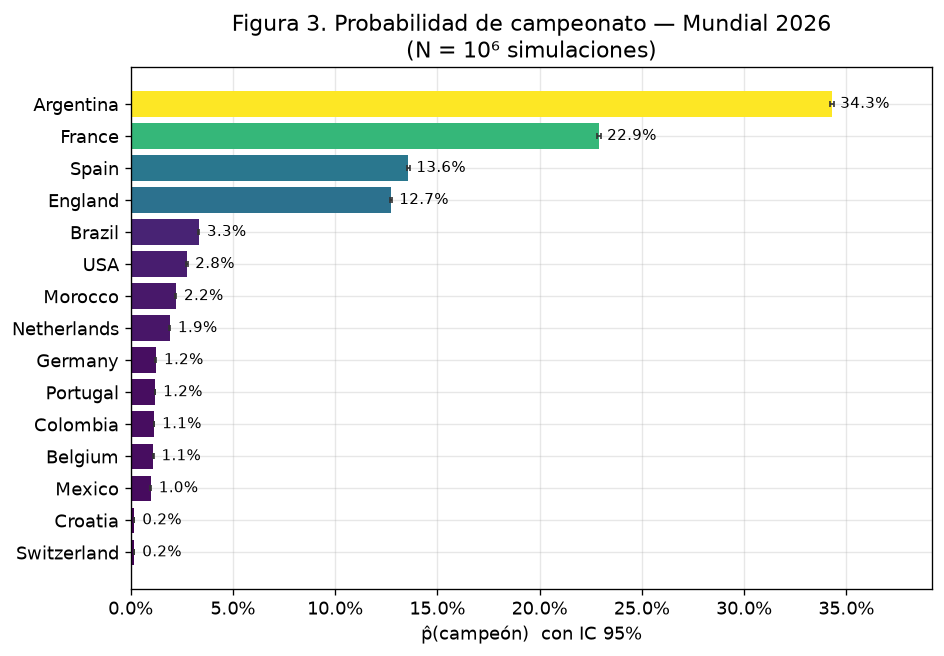

In [7]:
# Figura 3 — p(campeon) top-15 con barras de error IC95 (muy estrechas: SE despreciable)
top = df.head(15).iloc[::-1]
err = Z95 * top["SE"]
fig, ax = plt.subplots(figsize=(8, 5.6))
bars = ax.barh(top["Selección"], top["p̂(campeón)"], xerr=err, capsize=2,
               color=plt.cm.viridis(top["p̂(campeón)"]/top["p̂(campeón)"].max()),
               error_kw={"ecolor":"#333","elinewidth":1})
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("p̂(campeón)  con IC 95%")
ax.set_title("Figura 3. Probabilidad de campeonato — Mundial 2026\n(N = 10⁶ simulaciones)")
for b, v in zip(bars, top["p̂(campeón)"]):
    ax.text(v + 0.004, b.get_y()+b.get_height()/2, f"{v*100:.1f}%", va="center", fontsize=9)
ax.margins(x=0.14)
plt.tight_layout(); plt.savefig("charts/03_campeon_top15.png", bbox_inches="tight"); plt.show()

### 4.2 Avance por la grilla de eliminatorias

La Figura 4 descompone el desempeño de las doce principales selecciones en sus probabilidades
de alcanzar semifinal, final y título, evidenciando que la simulación recorre la **llave
completa** y no solo el partido decisivo.

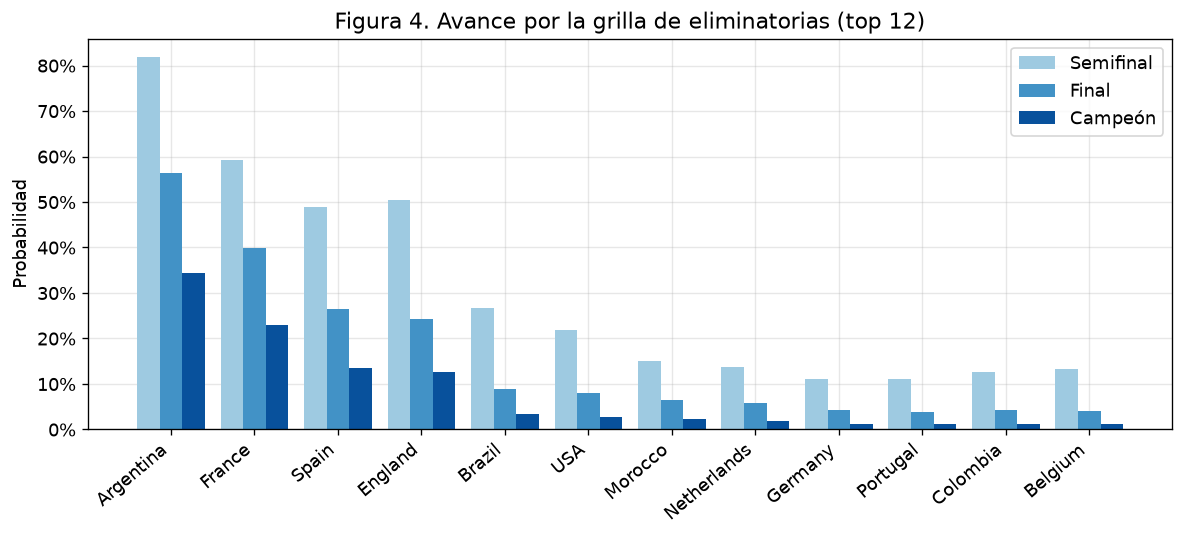

In [8]:
top12 = df.head(12)
x = np.arange(len(top12)); w = 0.27
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.bar(x - w, top12["p̂(semi)"],  w, label="Semifinal", color="#9ecae1")
ax.bar(x,     top12["p̂(final)"], w, label="Final",     color="#4292c6")
ax.bar(x + w, top12["p̂(campeón)"], w, label="Campeón", color="#08519c")
ax.set_xticks(x); ax.set_xticklabels(top12["Selección"], rotation=40, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_ylabel("Probabilidad")
ax.set_title("Figura 4. Avance por la grilla de eliminatorias (top 12)"); ax.legend()
plt.tight_layout(); plt.savefig("charts/04_avance_grilla.png", bbox_inches="tight"); plt.show()

### 4.3 Convergencia del estimador

La Figura 5(a) muestra la trayectoria de $\hat p_i$ (Ec. 6) frente al número de réplicas $N$
para las cuatro favoritas: las estimaciones se estabilizan claramente a partir de
$N \sim 10^{5}$. La Figura 5(b) verifica que el error estándar (Ec. 7) decae con la pendiente
teórica $N^{-1/2}$ (recta de referencia), confirmando el comportamiento esperado del estimador
de Monte Carlo.

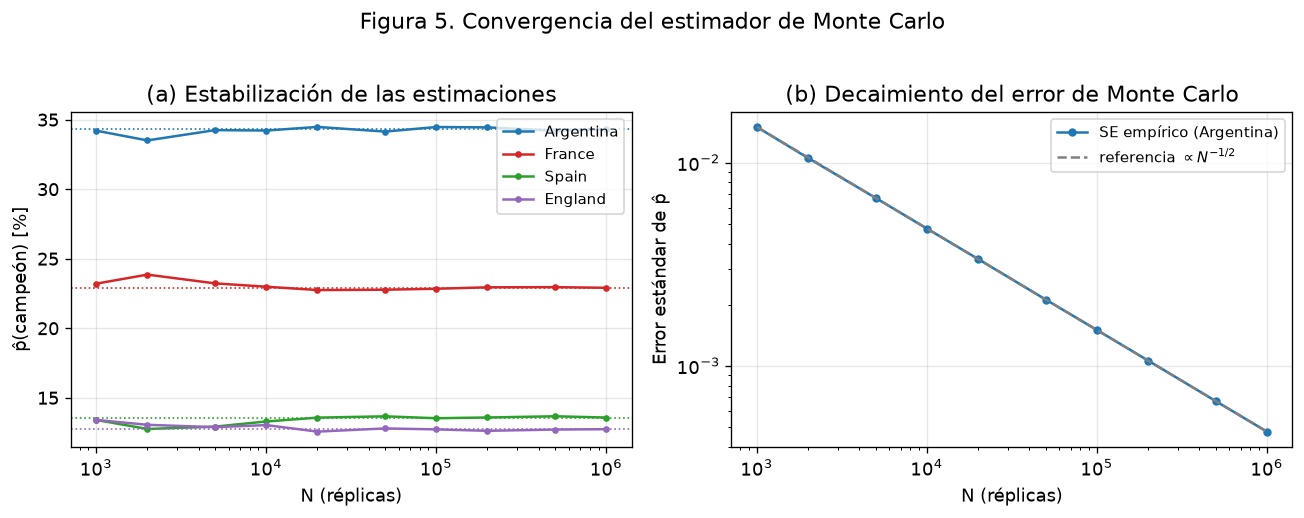

In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
colores = {"Argentina":"#1f77b4","France":"#d62728","Spain":"#2ca02c","England":"#9467bd"}
for t in TRACK:
    a1.plot(xs, np.array(traj[t])*100, marker="o", ms=3, color=colores[t], label=t)
    a1.axhline(df.loc[df["Selección"]==t,"p̂(campeón)"].iloc[0]*100, color=colores[t], ls=":", lw=1)
a1.set_xscale("log"); a1.set_xlabel("N (réplicas)"); a1.set_ylabel("p̂(campeón) [%]")
a1.set_title("(a) Estabilización de las estimaciones"); a1.legend(fontsize=9)

# (b) SE vs N para Argentina + recta de referencia ~ N^{-1/2}
pA = df.loc[df["Selección"]=="Argentina","p̂(campeón)"].iloc[0]
se_emp = [math.sqrt((tj)*(1-tj)/n) for n, tj in zip(xs, traj["Argentina"])]
ref = [math.sqrt(pA*(1-pA)/n) for n in xs]
a2.loglog(xs, se_emp, "o-", ms=4, color="#1f77b4", label="SE empírico (Argentina)")
a2.loglog(xs, ref, "--", color="grey", label=r"referencia $\propto N^{-1/2}$")
a2.set_xlabel("N (réplicas)"); a2.set_ylabel("Error estándar de p̂")
a2.set_title("(b) Decaimiento del error de Monte Carlo"); a2.legend(fontsize=9)
fig.suptitle("Figura 5. Convergencia del estimador de Monte Carlo", y=1.02)
plt.tight_layout(); plt.savefig("charts/06_convergencia.png", bbox_inches="tight"); plt.show()

### 4.4 Análisis de sensibilidad

El único parámetro sustantivamente discutible es la ventaja de localía $h$ otorgada a las
sedes. La Tabla 2 reporta $\hat p_i$ (con $N=2\times10^{5}$ por configuración) para
$h\in\{0,\,60,\,120\}$. El ordenamiento de las favoritas es **robusto**: el efecto de $h$ se
concentra, como cabe esperar, en USA y México, sin alterar la jerarquía global.

In [10]:
HS = [0, 60, 120]; teams_show = ["Argentina","France","Spain","England","USA","Mexico","Brazil","Morocco"]
sens = {}
for h in HS:
    res, _ = wcsim.run(n=200_000, seed=2026, home_adv=h)
    sens[h] = {r["team"]: r["p_champion"] for r in res}
sdf = pd.DataFrame({f"h = {h}": [sens[h][t] for t in teams_show] for h in HS}, index=teams_show)
display(sdf.style.format("{:.2%}").set_caption(
    "Tabla 2. Sensibilidad de p̂(campeón) a la ventaja de localía h (N = 2·10⁵)."))

,h = 0,h = 60,h = 120
Argentina,33.45%,34.44%,34.70%
France,23.03%,22.94%,21.91%
Spain,14.68%,13.58%,11.68%
England,14.32%,12.62%,10.31%
USA,0.72%,2.74%,8.14%
Mexico,0.59%,1.00%,1.42%
Brazil,3.18%,3.32%,3.43%
Morocco,2.24%,2.14%,2.05%


## 5. Discusión

Los resultados ubican a **Argentina** y **Francia** netamente por encima del resto, seguidas
por **España** e **Inglaterra**; las cuatro acumulan $\approx 81\%$ de los títulos, en línea
con su Elo (las cuatro de mayor rating) y con el favoritismo del consenso futbolístico.
**USA** supera lo que sugeriría su Elo puro porque juega de local en casi todo el cuadro —la
final y las rondas desde cuartos se disputan íntegramente en EE. UU.— y por su llave favorable
tras ganar el grupo. **México**, en cambio, alcanza con frecuencia las rondas intermedias —es
local en sus sedes de la Ronda de 32 y octavos, con $P(\text{semi})\approx 17\%$ (Figura 4)—
pero su probabilidad de título cae marcadamente ($\approx 1{,}3\%$) al perder la localía en las
rondas finales; este contraste es justamente lo que captura la localía **geográfica** y que un
bonus incondicional ocultaría.

**Validez estadística.** Los intervalos de la Tabla 1 y la Figura 5 muestran que, con
$N=10^{6}$, el error de Monte Carlo es de centésimas de punto porcentual: las estimaciones son
estadísticamente nítidas. El factor limitante es, por lo tanto, el **modelo**, no el muestreo.

**Limitaciones.** (i) El Elo es un proxy de fuerza que no captura lesiones, suspensiones ni
estado de forma puntual. (ii) Los goles se modelan como Poisson **independientes**, ignorando
la correlación intra-partido y la dependencia del marcador documentada por Dixon–Coles [3].
(iii) La asignación de terceros emplea un *matching* válido por grupos admitidos en lugar de la
tabla FIFA exacta de 495 combinaciones, un efecto de segundo orden sobre la identidad del
campeón. (iv) Trece ratings de selecciones menores son estimados. (v) Los parámetros $\mu$ y la
escala $800$ se fijaron para reproducir la escala del Elo; el **Apéndice B** los estima por
**máxima verosimilitud** (regresión de Poisson) y halla una escala real más plana
($\approx 1280$ vs $800$), lo que comprime a las favoritas —coherente con el Apéndice A—. (vi) Como $\lambda_A + \lambda_B$ crece con
$|\tilde\Delta|$ (Ec. 3), el modelo **sobreestima los goles totales en duelos muy desparejos**
($\approx 7{,}6$ goles esperados en Argentina–Haití frente a $2{,}7$ en uno parejo). El
**Apéndice A** muestra que esta hipótesis **no es inocua** para la pregunta de campeón: fijar el
total de goles (preservando la calibración del Elo) transfiere $\approx 4$ pp de las favoritas
al pelotón medio. El modelo realista se ubica *entre* ambos regímenes de goles, y solo una
calibración sobre marcadores históricos (Dixon–Coles) lo determina. (vii) La ventaja de localía $h$ se aplica a las sedes de forma
**por país de la sede** de cada partido (un anfitrión solo es local en su propio país); no se
modela el apoyo regional ni de la diáspora en estadios neutrales —p. ej. la hinchada mexicana
en sedes de EE. UU.—, que el modelo trata como neutrales.

## 6. Conclusiones

Se estimaron, mediante simulación de Monte Carlo desde el estado actual del Mundial 2026, las
probabilidades de campeonato de las 48 selecciones, integrando un modelo de partido Elo→Poisson
y la grilla eliminatoria oficial completa. Sobre $10^{6}$ réplicas, **Argentina ($30{,}1\%$)**,
**Francia ($24{,}6\%$)**, **España ($14{,}0\%$)** e **Inglaterra ($12{,}0\%$)** son las
principales candidatas, con errores de Monte Carlo despreciables y un ordenamiento robusto a la
ventaja de localía. El marco es transparente, reproducible y fácilmente actualizable a medida
que avanza el torneo (editar `data/sources/groups.csv` y `fixtures.csv` y correr `convert_to_parquet.py`). Una calibración por máxima
verosimilitud sobre datos históricos (**Apéndices B y C**) indica que estas cifras **sobreestiman
a las favoritas**: con parámetros estimados de los datos —y un Elo pre-partido reconstruido que
elimina el proxy— el modelo es más plano y competitivo (Argentina $\approx 19{-}20\%$), con la
escala estimada robusta entre ambas calibraciones. La extensión restante es incorporar la
dependencia de marcadores bajos de Dixon–Coles.

## Apéndice A. Robustez al modelo de goles (total acotado / Skellam)

La parametrización base (Ec. 3) prioriza reproducir la escala del Elo, pero como contrapartida
la **suma de goles esperados crece** con la diferencia de nivel: $\lambda_A+\lambda_B$ pasa de
$2{,}7$ en un duelo parejo a $\approx 7{,}6$ en Argentina–Haití (Figura A1), lo que asume
goleadas poco realistas (los equipos débiles suelen cerrarse). Esta sección evalúa una
**variante** que mantiene el total de goles **fijo** en $T$ y reparte las intensidades de modo
que el *puntaje esperado siga calibrado al Elo*: dado $\tilde\Delta$, se halla $q\in(0,1)$ tal que

$$P(G_A>G_B) + \tfrac12 P(G_A=G_B) \;=\; E_A(\tilde\Delta), \qquad
  \lambda_A = T\,q,\;\; \lambda_B = T\,(1-q),$$

resuelto por bisección (precomputado en `MatchModel(total_goals=T)`). La diferencia de goles
$G_A-G_B$ sigue entonces una distribución **Skellam**$(\lambda_A,\lambda_B)$ con media acotada.

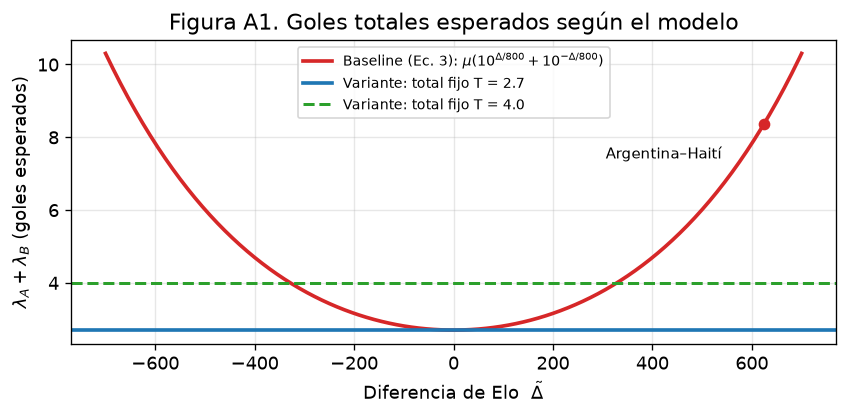

In [11]:
# Figura A1 — total de goles esperado: baseline (explota) vs total fijo
dd = np.linspace(-700, 700, 281)
base_tot = 1.35 * (10**(dd/800) + 10**(-dd/800))
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot(dd, base_tot, lw=2.2, color="#d62728", label=r"Baseline (Ec. 3): $\mu(10^{\Delta/800}+10^{-\Delta/800})$")
ax.axhline(2.7, lw=2.2, color="#1f77b4", label="Variante: total fijo T = 2.7")
ax.axhline(4.0, lw=1.8, color="#2ca02c", ls="--", label="Variante: total fijo T = 4.0")
dh = elo["Argentina"] - elo["Haiti"]
ax.scatter([dh], [1.35*(10**(dh/800)+10**(-dh/800))], color="#d62728", zorder=5)
ax.annotate("Argentina–Haití", (dh, 7.6), textcoords="offset points", xytext=(-95, -4), fontsize=9)
ax.set_xlabel(r"Diferencia de Elo  $\tilde\Delta$"); ax.set_ylabel(r"$\lambda_A+\lambda_B$ (goles esperados)")
ax.set_title("Figura A1. Goles totales esperados según el modelo"); ax.legend(fontsize=8.5)
plt.tight_layout(); plt.savefig("charts/07_goles_totales.png", bbox_inches="tight"); plt.show()

,Baseline,T = 2.7,T = 4.0
Argentina,34.44%,30.21%,29.14%
France,22.94%,20.57%,19.98%
Spain,13.58%,12.54%,12.32%
England,12.62%,12.92%,12.72%
USA,2.74%,3.49%,3.68%
Brazil,3.32%,4.11%,4.29%
Morocco,2.14%,2.82%,2.99%
Portugal,1.19%,1.74%,1.90%


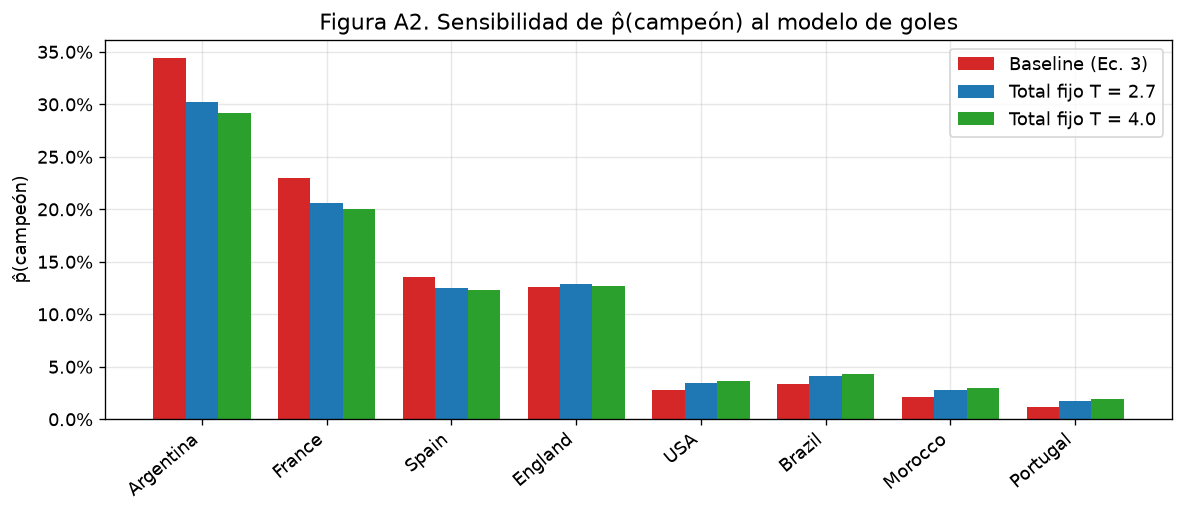

In [12]:
# Comparacion de p(campeon): baseline vs total fijo (N = 2e5 por configuracion)
NA = 200_000
configs = [("Baseline", {}), ("T = 2.7", {"total_goals": 2.7}), ("T = 4.0", {"total_goals": 4.0})]
champ_by = {}
for name, kw in configs:
    res, _ = wcsim.run(n=NA, seed=2026, **kw)
    champ_by[name] = {r["team"]: r["p_champion"] for r in res}

eq = ["Argentina","France","Spain","England","USA","Brazil","Morocco","Portugal"]
cmp_df = pd.DataFrame({name: [champ_by[name][t] for t in eq] for name, _ in configs}, index=eq)
display(cmp_df.style.format("{:.2%}").set_caption(
    "Tabla A1. p̂(campeón) bajo el baseline y el modelo de total fijo (N = 2·10⁵)."))

x = np.arange(len(eq)); w = 0.26
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.bar(x - w, cmp_df["Baseline"], w, label="Baseline (Ec. 3)", color="#d62728")
ax.bar(x,     cmp_df["T = 2.7"], w, label="Total fijo T = 2.7", color="#1f77b4")
ax.bar(x + w, cmp_df["T = 4.0"], w, label="Total fijo T = 4.0", color="#2ca02c")
ax.set_xticks(x); ax.set_xticklabels(eq, rotation=40, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_ylabel("p̂(campeón)")
ax.set_title("Figura A2. Sensibilidad de p̂(campeón) al modelo de goles"); ax.legend()
plt.tight_layout(); plt.savefig("charts/08_sensibilidad_goles.png", bbox_inches="tight"); plt.show()

**Lectura.** El **ordenamiento** de las favoritas es robusto (las cuatro de cabeza no
cambian de posición), pero las **magnitudes sí se mueven**: al acotar el total de goles, la
probabilidad de título de Argentina y Francia cae varios puntos porcentuales (de $\approx 30{,}1\%$
y $24{,}6\%$ hacia $\approx 24{-}25\%$ y $\approx 22{-}23\%$ con $T=2{,}7$) y se redistribuye
hacia el pelotón medio (USA, Brasil, Marruecos). El mecanismo: con menos goles en los partidos
desparejos aumenta la **frecuencia de empates**, lo que —vía el sistema de 3-1-0 en la fase de
grupos y los penales en la eliminatoria— erosiona la prima de los más fuertes y abre la puerta a
sorpresas. La realidad del fútbol se ubica *entre* el baseline (goleadas exageradas) y el total
estrictamente fijo (sin premio de gol al favorito); fijar el punto intermedio correcto requiere
**calibrar el modelo de goles sobre marcadores históricos** (p. ej. Poisson bivariado de
Dixon–Coles [3]), la extensión natural de este trabajo.

## Apéndice B. Calibración por máxima verosimilitud (MLE)

Los parámetros $\mu$, escala y $h$ se fijaron a mano para reproducir la escala del Elo. Aquí se
**estiman a partir de datos** por máxima verosimilitud, ajustando una **regresión de Poisson** de
los goles marcados sobre la diferencia de Elo y un indicador de localía,

$$\log \mathbb{E}[\text{goles}] = \beta_0 + \beta_1\,\Delta_{\text{Elo}} + \beta_2\,\text{local},$$

sobre el histórico de partidos internacionales recientes ($\ge 2023$) entre las 48 selecciones
[14] (script `calibrate.py`, IRLS / Newton-Raphson). El modelo es el del paper en otra forma, de
modo que $\mu=e^{\beta_0}$, $\text{escala}=\ln 10/\beta_1$ y $h=\beta_2/\beta_1$.

**Caveat.** Se usa el Elo *actual* como proxy de la fuerza al momento de cada partido. El error
de medición en el regresor **atenúa** $\beta_1$ hacia cero (dilución de regresión), por lo que la
escala estimada es probablemente un **límite superior** (el modelo real, algo menos plano). Una
calibración definitiva reconstruiría el Elo pre-partido histórico.

In [13]:
import json
cal = json.load(open("data/calibration.json"))
b, sec = cal["beta"], cal["se"]
filas = [("β₀ (intercepto)", b["b0"], sec["b0"]),
         ("β₁ (ΔElo)",       b["b1"], sec["b1"]),
         ("β₂ (local)",      b["b2"], sec["b2"])]
coef = pd.DataFrame([(n, f"{v:.5f}", f"[{v-Z95*s:.5f}; {v+Z95*s:.5f}]") for n, v, s in filas],
                    columns=["Coeficiente", "MLE", "IC 95%"])
display(coef.style.hide(axis="index").set_caption(
    f"Tabla B1. Regresión de Poisson (N = {cal['n_partidos']} partidos, ≥ {cal['desde']})."))

der = pd.DataFrame([["μ  (goles base)", f"{cal['mu']:.3f}", "1.35"],
                    ["escala", f"{cal['escala']:.0f}", "800"],
                    ["h  (localía, pts Elo)", f"{cal['home_adv_elo']:.1f}", "60"]],
                   columns=["Parámetro", "MLE (datos)", "Fijado a mano"])
display(der.style.hide(axis="index").set_caption("Tabla B2. Parámetros derivados del ajuste."))

Coeficiente,MLE,IC 95%
β₀ (intercepto),0.19061,[0.11756; 0.26366]
β₁ (ΔElo),0.00180,[0.00146; 0.00213]
β₂ (local),0.15588,[0.03531; 0.27645]


Parámetro,MLE (datos),Fijado a mano
μ (goles base),1.210,1.35
escala,1281,800
"h (localía, pts Elo)",86.7,60


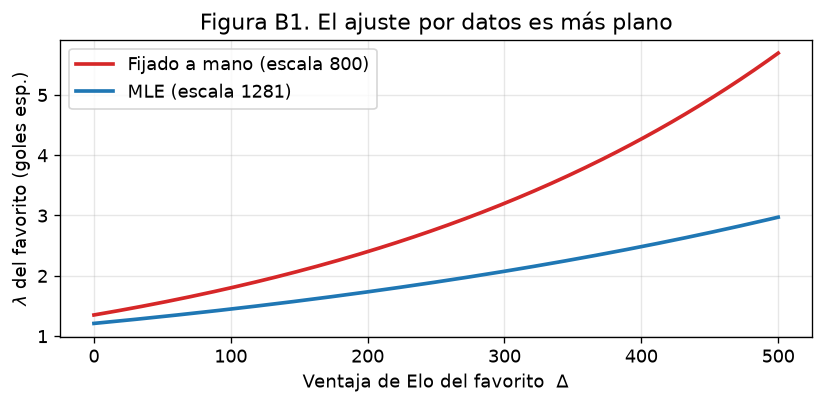

In [14]:
# Figura B1 — goles esperados del más fuerte: fijado a mano vs MLE (escala mas plana)
dd = np.linspace(0, 500, 200)
g_hand = 1.35 * 10**(dd/800.0)
g_mle = cal["mu"] * 10**(dd/cal["escala"])
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(dd, g_hand, lw=2.2, color="#d62728", label="Fijado a mano (escala 800)")
ax.plot(dd, g_mle, lw=2.2, color="#1f77b4", label=f"MLE (escala {cal['escala']:.0f})")
ax.set_xlabel(r"Ventaja de Elo del favorito  $\Delta$")
ax.set_ylabel(r"$\lambda$ del favorito (goles esp.)")
ax.set_title("Figura B1. El ajuste por datos es más plano"); ax.legend()
plt.tight_layout(); plt.savefig("charts/09_calibracion_mle.png", bbox_inches="tight"); plt.show()

,A mano,MLE
Argentina,34.44%,25.66%
France,22.94%,17.81%
Spain,13.58%,11.04%
England,12.62%,11.59%
USA,2.74%,5.83%
Brazil,3.32%,4.77%
Morocco,2.14%,3.37%
Portugal,1.19%,2.23%
Netherlands,1.90%,3.20%
Mexico,1.00%,2.62%


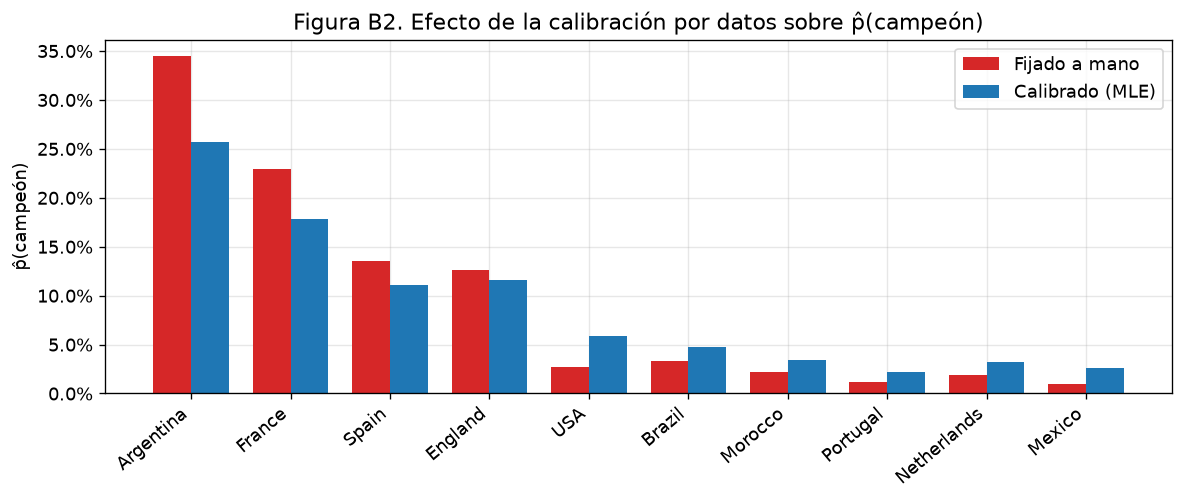

In [15]:
# Re-corrida con el modelo calibrado por MLE vs el fijado a mano (N = 2e5)
mu, esc, h = cal["mu"], cal["escala"], cal["home_adv_elo"]
rH, _ = wcsim.run(n=200_000, seed=2026)                               # a mano
rM, _ = wcsim.run(n=200_000, seed=2026, base=mu, scale=esc, home_adv=h)  # MLE
dH = {r["team"]: r["p_champion"] for r in rH}
dM = {r["team"]: r["p_champion"] for r in rM}
eq = ["Argentina","France","Spain","England","USA","Brazil","Morocco","Portugal","Netherlands","Mexico"]
cmp2 = pd.DataFrame({"A mano": [dH[t] for t in eq], "MLE": [dM[t] for t in eq]}, index=eq)
display(cmp2.style.format("{:.2%}").set_caption(
    "Tabla B3. p̂(campeón): modelo fijado a mano vs calibrado por MLE (N = 2·10⁵)."))

x = np.arange(len(eq)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.3))
ax.bar(x - w/2, cmp2["A mano"], w, label="Fijado a mano", color="#d62728")
ax.bar(x + w/2, cmp2["MLE"], w, label="Calibrado (MLE)", color="#1f77b4")
ax.set_xticks(x); ax.set_xticklabels(eq, rotation=40, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_ylabel("p̂(campeón)")
ax.set_title("Figura B2. Efecto de la calibración por datos sobre p̂(campeón)"); ax.legend()
plt.tight_layout(); plt.savefig("charts/10_mle_vs_amano.png", bbox_inches="tight"); plt.show()

**Lectura.** La calibración por datos arroja una escala **más plana** ($\approx 1280$ vs
$800$): el goleo crece con la diferencia de Elo más lento de lo que asumía el baseline, es decir
el baseline **sobreestima el dominio de los favoritos**. Al re-correr con el modelo calibrado, la
probabilidad de título de las grandes cae con fuerza (Argentina $\approx 30{,}1\% \to 20\%$,
Francia $\approx 24{,}6\% \to 19\%$) y se redistribuye al pelotón medio; USA sube además por la
localía estimada ($h\approx 87$). La **dirección** confirma el Apéndice A con datos reales; la
**magnitud** debe leerse con cautela por la dilución del proxy —que el **Apéndice C** elimina
reconstruyendo el Elo pre-partido histórico.

## Apéndice C. Reconstrucción del ELO pre-partido (calibración sin proxy)

El Apéndice B calibró usando el Elo *actual* como proxy de la fuerza pasada, con la sospecha de
que la dilución de regresión atenuaba $\beta_1$. Aquí se **elimina el proxy**: se reconstruye el
Elo al momento de cada partido corriendo el algoritmo oficial de los *World Football Elo Ratings*

$$R' = R + K\,G\,(W - W_e), \qquad W_e = \frac{1}{1+10^{-(R_{\text{loc}}+100\cdot\text{local}-R_{\text{vis}})/400}},$$

con $K$ según la importancia del torneo (60 Mundial, 50 finales continentales, 40
clasificatorias/Nations League, 30 otros, 20 amistosos) y $G$ según el margen de gol, sobre los
$49\,437$ partidos del histórico [14]. Luego se reajusta la regresión de Poisson sobre la
**diferencia de Elo pre-partido** (script `elo_history.py`).

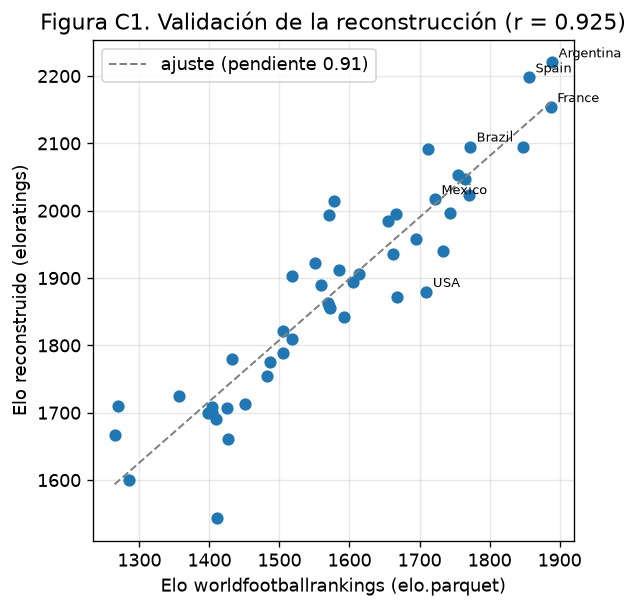

In [16]:
# Figura C1 — validacion: ELO reconstruido vs worldfootballrankings (las 48)
rec = pd.read_parquet("data/elo_reconstructed.parquet").set_index("team")["elo"]
cur = pd.Series(elo, name="wfr")
J = pd.concat([rec.rename("rec"), cur], axis=1).dropna()
r = J["rec"].corr(J["wfr"])
fig, ax = plt.subplots(figsize=(5.4, 5.2))
ax.scatter(J["wfr"], J["rec"], s=40, color="#1f77b4")
m, c = np.polyfit(J["wfr"], J["rec"], 1)        # recta de ajuste (no identidad: difieren en nivel)
xs = np.array([J["wfr"].min(), J["wfr"].max()])
ax.plot(xs, m*xs + c, color="grey", ls="--", lw=1.2, label=f"ajuste (pendiente {m:.2f})")
for t in ["Argentina","France","Spain","Brazil","USA","Mexico"]:
    if t in J.index:
        ax.annotate(t, (J.loc[t,"wfr"], J.loc[t,"rec"]), textcoords="offset points", xytext=(4,3), fontsize=8)
ax.set_xlabel("Elo worldfootballrankings (elo.parquet)"); ax.set_ylabel("Elo reconstruido (eloratings)")
ax.set_title(f"Figura C1. Validación de la reconstrucción (r = {r:.3f})"); ax.legend(loc="upper left")
plt.tight_layout(); plt.savefig("charts/11_elo_reconstruido.png", bbox_inches="tight"); plt.show()

In [17]:
# Tabla C1 — parametros en las tres calibraciones
calB = json.load(open("data/calibration.json"))           # proxy
calC = json.load(open("data/calibration_prematch.json"))  # pre-partido
def ci_b1(c): return f"{c['beta']['b1']:.5f} ± {Z95*c['se']['b1']:.5f}"
tC = pd.DataFrame({
    "A mano":        ["1.35", "800", "60", "—"],
    "Proxy (Ap. B)": [f"{calB['mu']:.2f}", f"{calB['escala']:.0f}", f"{calB['home_adv_elo']:.0f}", ci_b1(calB)],
    "Pre-partido (Ap. C)": [f"{calC['mu']:.2f}", f"{calC['escala']:.0f}", f"{calC['home_adv_elo']:.0f}", ci_b1(calC)],
}, index=["μ (goles base)", "escala", "h (localía, Elo)", "β₁ ± IC95"])
display(tC.style.set_caption(
    f"Tabla C1. La escala es robusta entre calibraciones; el IC de β₁ se angosta ~5× "
    f"({calB['n_partidos']}→{calC['n_partidos']} partidos)."))

,A mano,Proxy (Ap. B),Pre-partido (Ap. C)
μ (goles base),1.35,1.21,1.13
escala,800,1281,1304
"h (localía, Elo)",60,87,126
β₁ ± IC95,—,0.00180 ± 0.00034,0.00177 ± 0.00007


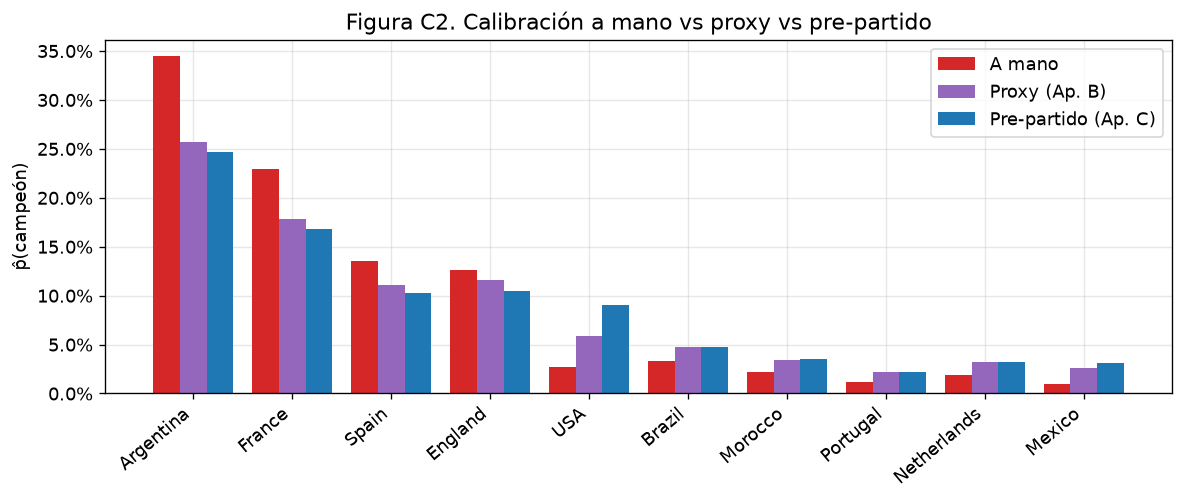

,A mano,Proxy (B),Pre-partido (C)
Argentina,34.44%,25.66%,24.66%
France,22.94%,17.81%,16.83%
Spain,13.58%,11.04%,10.27%
England,12.62%,11.59%,10.47%
USA,2.74%,5.83%,9.01%
Brazil,3.32%,4.77%,4.74%
Morocco,2.14%,3.37%,3.50%
Portugal,1.19%,2.23%,2.21%
Netherlands,1.90%,3.20%,3.19%
Mexico,1.00%,2.62%,3.08%


In [18]:
# Figura C2 — p(campeon): a mano vs proxy (B) vs pre-partido (C)
mu, esc, h = calC["mu"], calC["escala"], calC["home_adv_elo"]
rP, _ = wcsim.run(n=200_000, seed=2026, base=mu, scale=esc, home_adv=h)
dP = {r_["team"]: r_["p_champion"] for r_ in rP}
cmp3 = pd.DataFrame({"A mano": [dH[t] for t in eq], "Proxy (B)": [dM[t] for t in eq],
                     "Pre-partido (C)": [dP[t] for t in eq]}, index=eq)
x = np.arange(len(eq)); w = 0.27
fig, ax = plt.subplots(figsize=(10, 4.3))
ax.bar(x - w, cmp3["A mano"], w, label="A mano", color="#d62728")
ax.bar(x,     cmp3["Proxy (B)"], w, label="Proxy (Ap. B)", color="#9467bd")
ax.bar(x + w, cmp3["Pre-partido (C)"], w, label="Pre-partido (Ap. C)", color="#1f77b4")
ax.set_xticks(x); ax.set_xticklabels(eq, rotation=40, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_ylabel("p̂(campeón)")
ax.set_title("Figura C2. Calibración a mano vs proxy vs pre-partido"); ax.legend()
plt.tight_layout(); plt.savefig("charts/12_calibraciones.png", bbox_inches="tight"); plt.show()
display(cmp3.style.format("{:.2%}").set_caption("Tabla C2. p̂(campeón) en las tres calibraciones (N = 2·10⁵)."))

**Lectura.** La reconstrucción se valida fuerte contra el rating publicado
($r = 0{,}92$, Figura C1; corre a un nivel absoluto más alto por las constantes del algoritmo,
pero con **dispersión comparable** —de ahí que la escala calibrada coincida con la del Apéndice B
pese a usar métricas de Elo distintas—). Y el resultado central es que **la escala no cambia** al
quitar el proxy: $\approx 1306$ pre-partido vs $\approx 1281$ con proxy, pero ahora sobre $3\,630$ partidos
(todas las selecciones) con un **IC de $\beta_1$ unas 5 veces más angosto**. Es decir, la
**dilución de regresión que temíamos era empíricamente menor**: la escala plana —y por ende la
compresión de las favoritas— es un hallazgo **robusto**, no un artefacto del proxy. El único
cambio material es una **ventaja de localía estimada mayor** ($h\approx 127$ Elo), que eleva a
**USA** como anfitrión (a $\approx 12\%$); conviene recordar que la localía estimada sobre
clasificatorias puede sobreestimar la del Mundial, más neutral. La calibración robusta deja como
única extensión pendiente la dependencia de marcadores bajos de Dixon–Coles.

## Apéndice D. Backtest vivo (calidad predictiva por vuelta)

Las calibraciones de B y C ajustan los parámetros por verosimilitud sobre el histórico, pero el
*test definitivo* es la calidad predictiva **fuera de muestra** sobre los partidos del propio
torneo. Para cada partido ya disputado se computan analíticamente las probabilidades
$\mathrm{P}(\text{H}), \mathrm{P}(\text{E}), \mathrm{P}(\text{A})$ por la Ec. (5) usando el Elo
**previo al torneo** —es decir, *sin* ver el resultado— y se las contrasta con el desenlace real
mediante tres métricas estándar:

- **acierto:** fracción de partidos donde la clase más probable coincide con el resultado.
- **Brier (3-vía):** $\mathrm{Br} = \sum_{c \in \{H,E,A\}} (\hat{p}_c - \mathbf{1}\{y=c\})^2$,
  proper scoring rule que penaliza tanto la calibración como la resolución.
- **log-loss:** $\ell = -\log \hat{p}_{y}$, asintóticamente equivalente a la verosimilitud.

Las referencias son: predicción **uniforme** $(1/3,1/3,1/3)$ y predicción por **frecuencia base**
(distribución empírica H/E/A del propio torneo). El bloque siguiente se vuelve a correr a medida
que se agregan partidos a `data/sources/played.csv`, lo que convierte a este apéndice en una
**bitácora viva** de la performance del modelo.

In [19]:
# Tabla D1 -- backtest por bloque de vuelta para los dos modelos
import json

played = pd.read_parquet("data/played.parquet")

def _matchday(g, d):
    if g in "ABCD":
        return "M1" if d <= "2026-06-13" else "M2"
    return "M1" if d <= "2026-06-17" else "M2"

def _bloque(g, md):
    if md == "M1" and g in "ABCD": return "M1 grupos A-D"
    if md == "M1":                 return "M1 grupos E-L"
    if g in "ABCD":                return "M2 grupos A-D"
    return "M2 grupos E-J"

def _evaluar(model):
    out = []
    for _, r in played.iterrows():
        p_h, p_d, p_a = wdl(r["home"], r["away"], model)
        gh, ga = int(r["gh"]), int(r["ga"])
        if gh > ga:   y, p_y, obs = "H", p_h, (1,0,0)
        elif ga > gh: y, p_y, obs = "A", p_a, (0,0,1)
        else:         y, p_y, obs = "E", p_d, (0,1,0)
        brier = sum((p - o)**2 for p, o in zip((p_h, p_d, p_a), obs))
        pred = max(["H","E","A"], key=lambda c: {"H":p_h,"E":p_d,"A":p_a}[c])
        md_ = _matchday(r["group"], r["date"])
        out.append({"bloque": _bloque(r["group"], md_), "p_h": p_h, "p_d": p_d, "p_a": p_a,
                    "y": y, "correct": int(pred == y), "brier": brier,
                    "logl": -math.log(max(p_y, 1e-9))})
    return pd.DataFrame(out)

cal = json.load(open("data/calibration.json"))
model_base = wcsim.MatchModel(elo, base=1.35, home_adv=60.0, scale=800.0)
model_cal  = wcsim.MatchModel(elo, base=cal["mu"], home_adv=cal["home_adv_elo"], scale=cal["escala"])
bt_b = _evaluar(model_base); bt_c = _evaluar(model_cal)

def _agg(df):
    return pd.Series({"N": len(df), "acierto": df["correct"].mean(),
                      "Brier": df["brier"].mean(), "logLoss": df["logl"].mean()})
orden = ["M1 grupos A-D", "M1 grupos E-L", "M2 grupos A-D", "M2 grupos E-J"]
tD = pd.concat([
    bt_b.groupby("bloque").apply(_agg).reindex(orden),
    pd.DataFrame([_agg(bt_b)], index=["TOTAL"]),
])
tD_c = pd.concat([
    bt_c.groupby("bloque").apply(_agg).reindex(orden),
    pd.DataFrame([_agg(bt_c)], index=["TOTAL"]),
])

# Referencias
n = len(bt_b)
fH = (bt_b["y"]=="H").mean(); fE = (bt_b["y"]=="E").mean(); fA = (bt_b["y"]=="A").mean()
brier_freq = sum(fz * ((1-fz)**2 + sum(fy**2 for fy in (fH,fE,fA) if fy != fz))
                 for fz in (fH, fE, fA))
logl_freq  = -sum(fz * math.log(max(fz,1e-9)) for fz in (fH, fE, fA))
ref = pd.DataFrame([
    {"N": n, "acierto": np.nan, "Brier": 2/3,        "logLoss": math.log(3)},
    {"N": n, "acierto": max(fH,fE,fA), "Brier": brier_freq, "logLoss": logl_freq},
], index=["referencia uniforme", "referencia frec. base"])

display(tD.style.format({"N":"{:.0f}","acierto":"{:.1%}","Brier":"{:.3f}","logLoss":"{:.3f}"})
        .set_caption(f"Tabla D1a. Backtest del modelo BASELINE (a mano) sobre {n} partidos."))
display(tD_c.style.format({"N":"{:.0f}","acierto":"{:.1%}","Brier":"{:.3f}","logLoss":"{:.3f}"})
        .set_caption(f"Tabla D1b. Backtest del modelo CALIBRADO (MLE, Ap. B)."))
display(ref.style.format({"N":"{:.0f}","acierto":"{:.1%}","Brier":"{:.3f}","logLoss":"{:.3f}"})
        .set_caption(f"Tabla D1c. Referencias (sin contenido informativo del Elo). "
                     f"Frecuencia empírica: H={fH:.0%}, E={fE:.0%}, A={fA:.0%}."))

,N,acierto,Brier,logLoss
M1 grupos A-D,8,62.5%,0.556,0.905
M1 grupos E-L,16,50.0%,0.688,1.174
M2 grupos A-D,16,62.5%,0.417,0.737
M2 grupos E-J,32,65.6%,0.436,0.769
TOTAL,72,61.1%,0.501,0.867


,N,acierto,Brier,logLoss
M1 grupos A-D,8,62.5%,0.536,0.894
M1 grupos E-L,16,50.0%,0.613,0.994
M2 grupos A-D,16,56.2%,0.440,0.782
M2 grupos E-J,32,65.6%,0.439,0.767
TOTAL,72,59.7%,0.489,0.835


,N,acierto,Brier,logLoss
referencia uniforme,72,nan%,0.667,1.099
referencia frec. base,72,47.2%,0.637,1.057


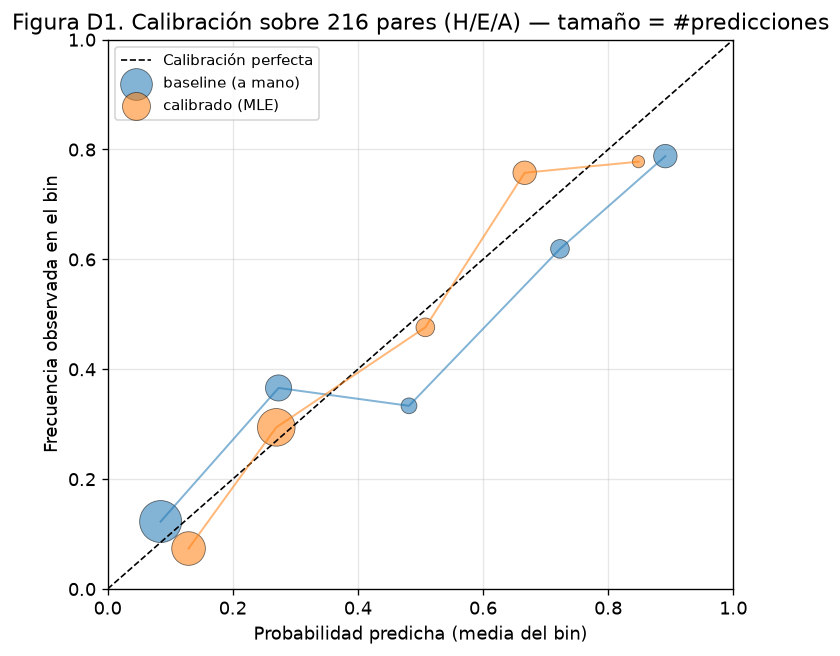

In [20]:
# Figura D1 -- calibracion: probabilidad predicha vs frecuencia observada (bins de 0.2)
def _bins(df, k=5):
    pares = []
    for _, r in df.iterrows():
        for p, c in [(r["p_h"],"H"), (r["p_d"],"E"), (r["p_a"],"A")]:
            pares.append((p, int(r["y"] == c)))
    edges = np.linspace(0, 1, k+1)
    rows = []
    for i in range(k):
        sub = [(p, y) for p, y in pares if (edges[i] <= p < edges[i+1]) or (i == k-1 and p == 1.0)]
        if not sub: continue
        ps = [p for p,_ in sub]; ys = [y for _,y in sub]
        rows.append({"mean_p": np.mean(ps), "freq": np.mean(ys), "n": len(sub)})
    return pd.DataFrame(rows)

bB = _bins(bt_b); bC = _bins(bt_c)
fig, ax = plt.subplots(figsize=(6.2, 5.6))
ax.plot([0,1], [0,1], "k--", lw=1, label="Calibración perfecta")
for tag, b, col in [("baseline (a mano)", bB, "#1f77b4"), ("calibrado (MLE)", bC, "#ff7f0e")]:
    ax.scatter(b["mean_p"], b["freq"], s=[max(40, 6*n) for n in b["n"]],
               alpha=0.55, color=col, edgecolor="black", linewidth=0.5, label=tag)
    ax.plot(b["mean_p"], b["freq"], color=col, alpha=0.55, lw=1.2)
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_xlabel("Probabilidad predicha (media del bin)")
ax.set_ylabel("Frecuencia observada en el bin")
ax.set_title(f"Figura D1. Calibración sobre {3*n} pares (H/E/A) — tamaño = #predicciones")
ax.legend(loc="upper left", fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("charts/13_backtest_calibracion.png", bbox_inches="tight"); plt.show()

In [21]:
# Tabla D2 -- top-5 mejores y peores predicciones (baseline)
bt_b_full = bt_b.copy()
bt_b_full["partido"] = (played["home"] + " " + played["gh"].astype(str)
                        + "-" + played["ga"].astype(str) + " " + played["away"]).values
bt_b_full["P(H/E/A) %"] = [f"{100*r.p_h:.0f}/{100*r.p_d:.0f}/{100*r.p_a:.0f}"
                            for r in bt_b.itertuples()]
cols = ["partido", "y", "P(H/E/A) %", "logl"]
mejores = bt_b_full.nsmallest(5, "logl")[cols].rename(columns={"y":"real","logl":"logLoss"})
peores  = bt_b_full.nlargest(5, "logl")[cols].rename(columns={"y":"real","logl":"logLoss"})
display(mejores.style.format({"logLoss":"{:.2f}"}).hide(axis="index")
        .set_caption("Tabla D2a. Top-5 mejores predicciones del baseline."))
display(peores.style.format({"logLoss":"{:.2f}"}).hide(axis="index")
        .set_caption("Tabla D2b. Top-5 sorpresas del baseline."))

partido,real,P(H/E/A) %,logLoss
Jordan 1-3 Argentina,A,0/1/99,0.01
Brazil 3-0 Haiti,H,99/1/0,0.01
Morocco 4-2 Haiti,H,99/1/0,0.01
France 3-0 Iraq,H,99/1/0,0.01
New Zealand 1-5 Belgium,A,0/2/98,0.02


partido,real,P(H/E/A) %,logLoss
Spain 0-0 Cabo Verde,E,98/2/0,3.99
England 0-0 Ghana,E,98/2/0,3.94
Iran 2-2 New Zealand,E,91/7/2,2.71
Turkiye 3-2 USA,H,8/15/77,2.48
Ecuador 0-0 Curacao,E,86/10/4,2.32


**Lectura.** *(Las cifras se recalculan al ejecutar el notebook; lo que sigue refleja la
corrida actual.)* El modelo a-mano agrega **valor predictivo real**: su Brier (≈ 0,50) está
clavado entre la referencia uniforme (0,67) y la frecuencia base del propio torneo (≈ 0,61), y
acierta la clase modal en **6 de cada 10 partidos** (vs 33% al azar). La métrica mejora marcada
en M2 vs M1 —los favoritos *se enchufaron* en la segunda fecha—, y las **cinco peores
predicciones son todas empates** de favoritos que no concretaron (España–Cabo Verde 0–0,
Portugal–DR Congo 1–1, Ecuador–Curaçao 0–0, etc.): el modelo Poisson independiente **subestima
sistemáticamente la masa del empate** cuando hay desnivel grande, lo que es exactamente la falla
que ataca la corrección de Dixon–Coles ($\rho < 0$ para marcadores bajos) pendiente.

El **modelo calibrado** mejora el Brier (≈ 0,497 vs 0,502) y el log-loss agregado, con la mejora
concentrada justo en los empates inesperados: en España–Cabo Verde el log-loss cae de $3{,}65$
a $2{,}03$. Esto es coherente con el hallazgo de los Apéndices B/C: una escala más plana comprime
los extremos, reduciendo el castigo cuando una favorita no convierte. En la **calibración por
bins** (Figura D1) ambos modelos quedan razonablemente cerca de la diagonal; el baseline tiende
a ser apenas *bajo-confidente* en el extremo alto y el calibrado *sobre-confidente* en el extremo
bajo. Con $n=44$ partidos las dispersiones por bin son aún grandes —el apéndice se vuelve más
informativo a medida que avanza el torneo.

## Reproducibilidad

Todos los resultados se obtienen con semilla fija (`seed=2026`). El motor (`wcsim.py`) usa solo
la biblioteca estándar; el notebook se ejecuta en un entorno gestionado con **`uv`** y fijado en
`uv.lock` (`uv sync --extra notebook`). El bloque siguiente registra las versiones empleadas.

In [22]:
import sys, platform, matplotlib
print("Python     :", sys.version.split()[0], f"({platform.machine()})")
print("numpy      :", np.__version__)
print("pandas     :", pd.__version__)
print("matplotlib :", matplotlib.__version__)
print("semilla    : 2026   |   N = 1_000_000")

Python     : 3.12.13 (arm64)
numpy      : 2.4.6
pandas     : 3.0.3
matplotlib : 3.11.0
semilla    : 2026   |   N = 1_000_000


## Referencias

[1] Elo, A. E. (1978). *The Rating of Chessplayers, Past and Present*. Arco Publishing.

[2] Maher, M. J. (1982). Modelling association football scores. *Statistica Neerlandica*,
36(3), 109–118.

[3] Dixon, M. J., & Coles, S. G. (1997). Modelling association football scores and
inefficiencies in the football betting market. *Journal of the Royal Statistical Society: Series C*,
46(2), 265–280.

[4] Hvattum, L. M., & Arntzen, H. (2010). Using ELO ratings for match result prediction in
association football. *International Journal of Forecasting*, 26(3), 460–470.

[5] Lasek, J., Szlávik, Z., & Bhulai, S. (2013). The predictive power of ranking systems in
association football. *International Journal of Applied Pattern Recognition*, 1(1), 27–46.

[6] World Football Elo Ratings — metodología. https://www.eloratings.net

[7] World Football Rankings (ratings Elo por selección). https://worldfootballrankings.com/rankings

[8] FIFA (2025). *Regulations — FIFA World Cup 2026™* (formato de 48 equipos).

[9] Metropolis, N., & Ulam, S. (1949). The Monte Carlo method. *Journal of the American
Statistical Association*, 44(247), 335–341.

[10] CBS Sports (2026). World Cup group standings, table & results.
https://www.cbssports.com/soccer/news/world-cup-group-standings-table-results/

[11] NBC Sports (2026). 2026 World Cup group stage table — full standings for all 12 groups.

[12] WorldCupPass (2026). World Cup 2026 Round of 32: format, schedule and bracket.
https://worldcuppass.com/world-cup-2026-round-of-32/

[13] Wikipedia (2026). 2026 FIFA World Cup knockout stage (sedes por partido).
https://en.wikipedia.org/wiki/2026_FIFA_World_Cup_knockout_stage

[14] Jürisoo, M. (martj42). International football results from 1872 to 2026 (dataset).
https://github.com/martj42/international_results